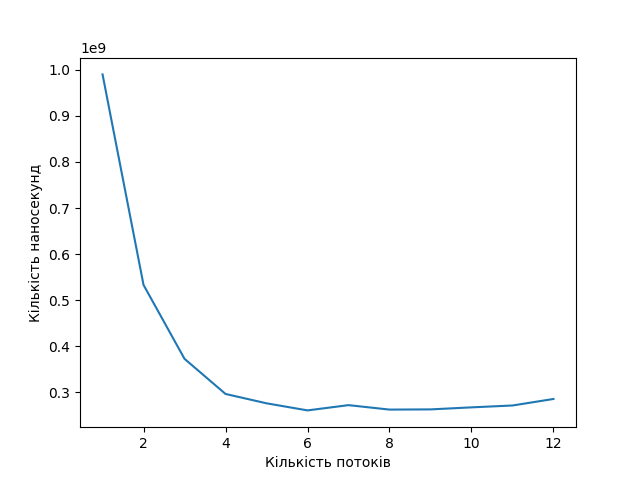

In [80]:
import typing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget


count_words_single = pd.read_csv('count_words_single.csv')
count_words_multi = pd.read_csv('count_words_multi.csv')

count_words_data = count_words_multi.groupby(['threads_count']).mean()
count_words_data.loc[1] = count_words_single.mean()
count_words_data = count_words_data.sort_index()

fig, axes = plt.subplots(1)
axes.set_xlabel('Кількість потоків')
axes.set_ylabel('Кількість наносекунд')
axes.plot(count_words_data.index, count_words_data.values)

plt.savefig('count_words.png', dpi=300, bbox_inches='tight')

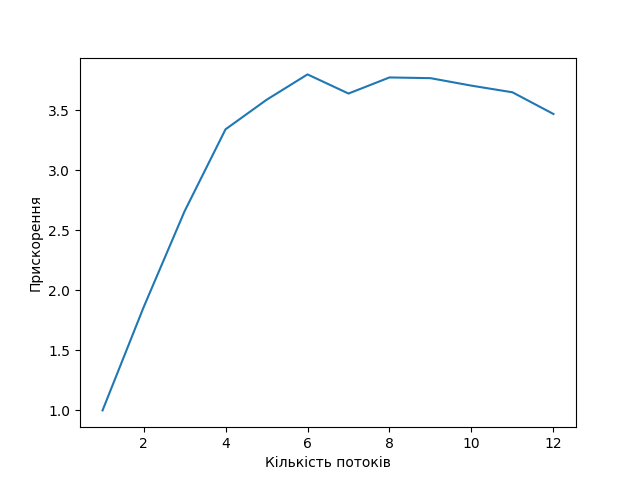

In [81]:
count_words_data /= count_words_data.loc[1]
count_words_data = 1.0 / count_words_data
fig, axes = plt.subplots(1)
axes.set_xlabel('Кількість потоків')
axes.set_ylabel('Прискорення')
axes.plot(count_words_data.index, count_words_data.values)
plt.savefig('count_words_speedup.png', dpi=300, bbox_inches='tight')

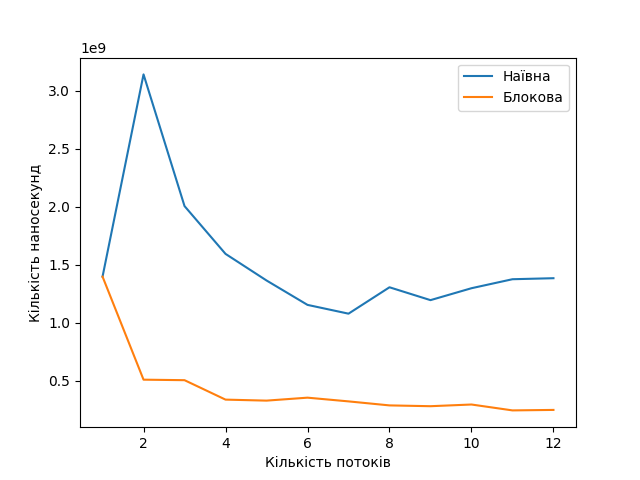

In [82]:
import typing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_single = pd.read_csv('matrix_transpose_single.csv')
data_multi = pd.read_csv('matrix_transpose_multi.csv')
data_block = pd.read_csv('matrix_transpose_block.csv')

data_multi = data_multi.groupby(['threads_count']).mean()
data_block = data_block.groupby(['threads_count']).mean()

data_multi.loc[1] = data_single.mean()
data_multi = data_multi.sort_index()

data_block.loc[1] = data_single.mean()
data_block = data_block.sort_index()

fig, axes = plt.subplots(1)
axes.set_xlabel('Кількість потоків')
axes.set_ylabel('Кількість наносекунд')
axes.plot(data_multi.index, data_multi.values, label='Наївна')
axes.plot(data_block.index, data_block.values, label='Блокова')
axes.legend()
plt.savefig('matrix_transpose.png', dpi=300, bbox_inches='tight')

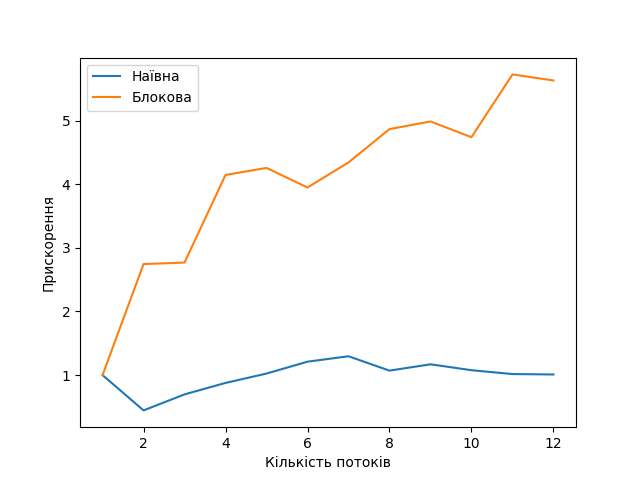

In [83]:
data_multi /= data_multi.loc[1]
data_multi = 1.0 / data_multi

data_block /= data_block.loc[1]
data_block = 1.0 / data_block

fig, axes = plt.subplots(1)
axes.set_xlabel('Кількість потоків')
axes.set_ylabel('Прискорення')
axes.plot(data_multi.index, data_multi.values, label='Наївна')
axes.plot(data_block.index, data_block.values, label='Блокова')
axes.legend()
plt.savefig('matrix_transpose_speedup.png', dpi=300, bbox_inches='tight')

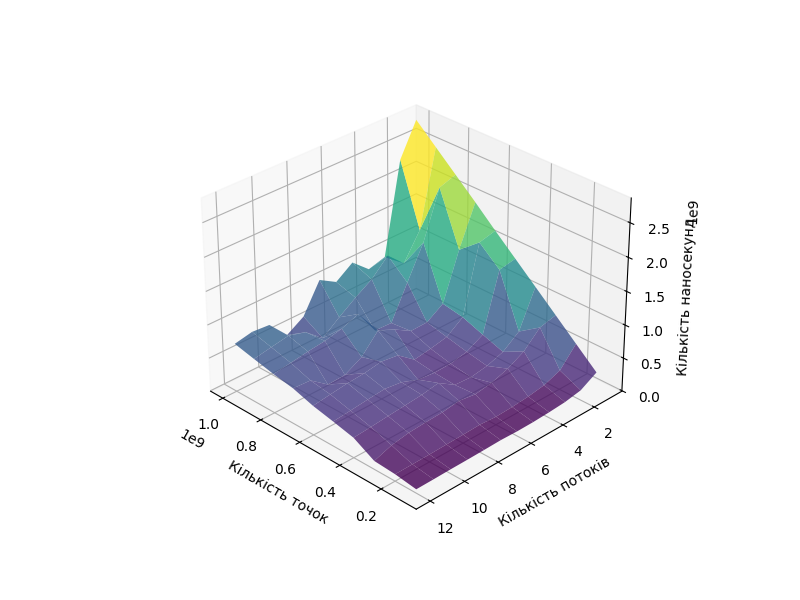

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_single = pd.read_csv('pi_monte_single.csv')
data_single['threads_count'] = 1
data_multi = pd.read_csv('pi_monte_multi.csv')

data_single = data_single[['threads_count', 'points_count', 'nanoseconds']]
data_multi = data_multi[['threads_count', 'points_count', 'nanoseconds']]

data_single = data_single.groupby(['threads_count', 'points_count']).mean()
data_multi = data_multi.groupby(['threads_count', 'points_count']).mean()

data = pd.concat([data_single, data_multi])

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111, projection='3d')
ax1.set_xlabel('Кількість точок')
ax1.set_ylabel('Кількість потоків')
ax1.set_zlabel('Кількість наносекунд')

pivot_df = data['nanoseconds'].unstack()

X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.view_init(elev=30, azim=135)
plt.savefig('pi_monte.png', dpi=300, bbox_inches='tight')

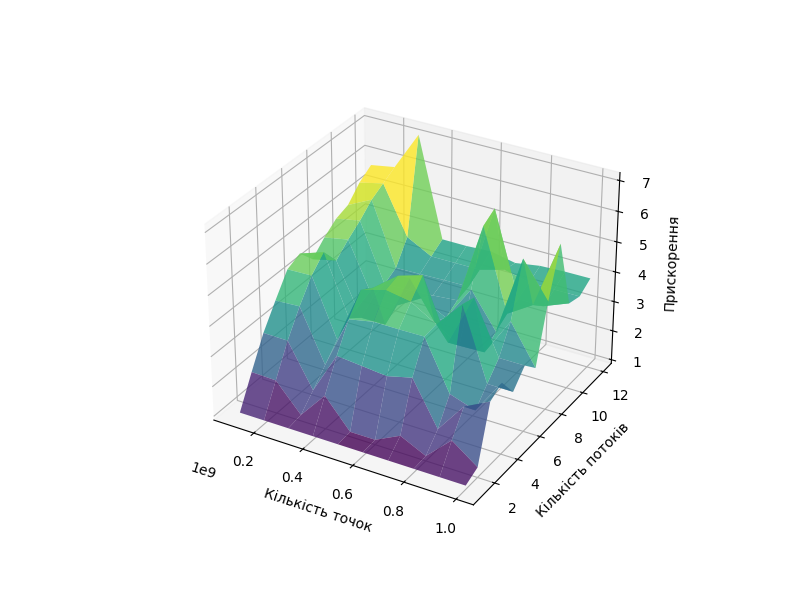

In [85]:
data['speedup'] = data.groupby('points_count')['nanoseconds'].transform(lambda x: x.iloc[0] / x)

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111, projection='3d')
ax1.set_xlabel('Кількість точок')
ax1.set_ylabel('Кількість потоків')
ax1.set_zlabel('Прискорення')

pivot_df = data['speedup'].unstack()

X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
plt.savefig('pi_monte_speedup.png', dpi=300, bbox_inches='tight')

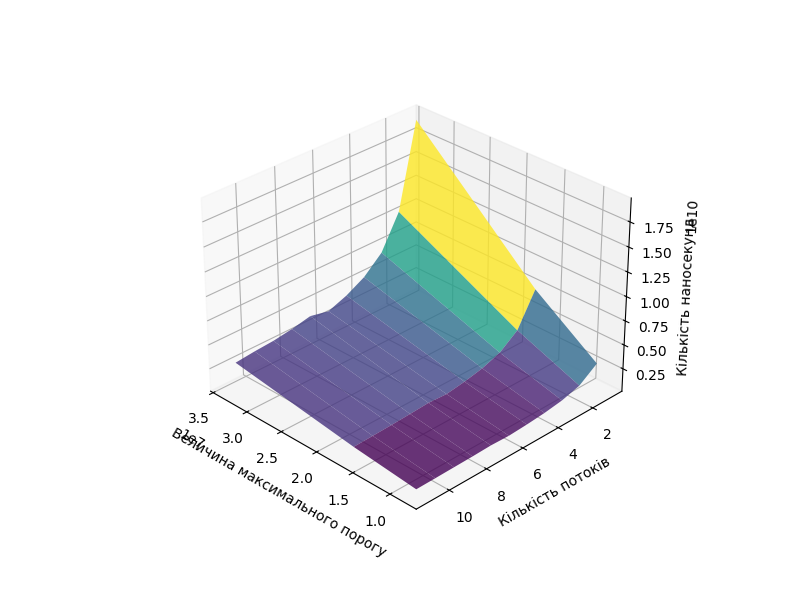

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_single = pd.read_csv('prime_slice_single.csv')
data_single['threads_count'] = 1
data_multi = pd.read_csv('prime_slice_multi.csv')

data_single = data_single[['threads_count', 'mmax', 'nanoseconds']]
data_multi = data_multi[['threads_count', 'mmax', 'nanoseconds']]

data_single = data_single.groupby(['threads_count', 'mmax']).mean()
data_multi = data_multi.groupby(['threads_count', 'mmax']).mean()

data = pd.concat([data_single, data_multi])

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111, projection='3d')
ax1.set_xlabel('Величина максимального порогу')
ax1.set_ylabel('Кількість потоків')
ax1.set_zlabel('Кількість наносекунд')


pivot_df = data['nanoseconds'].unstack()

X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.view_init(elev=30, azim=135)
plt.savefig('prime_slice.png', dpi=300, bbox_inches='tight')

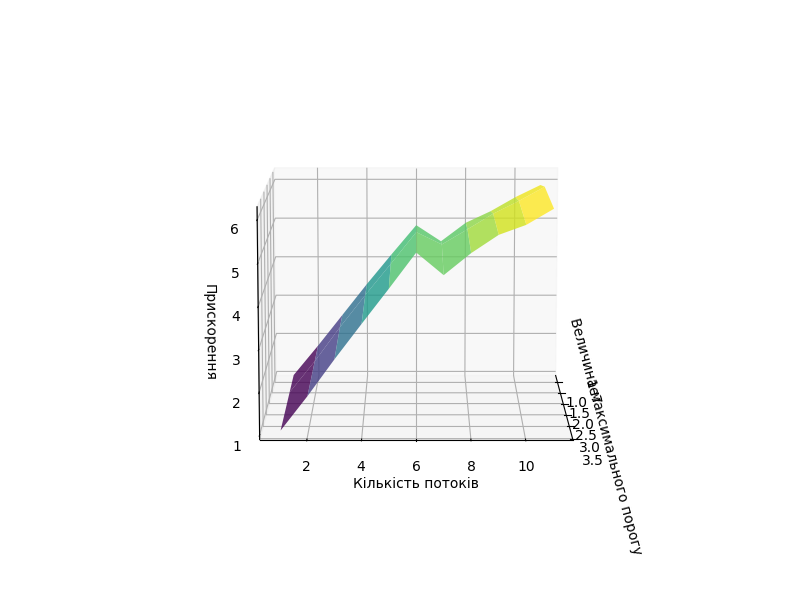

In [87]:
data['speedup'] = data.groupby('mmax')['nanoseconds'].transform(lambda x: x.iloc[0] / x)

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111, projection='3d')
ax1.set_xlabel('Величина максимального порогу')
ax1.set_ylabel('Кількість потоків')
ax1.set_zlabel('Прискорення')

pivot_df = data['speedup'].unstack()

X, Y = np.meshgrid(pivot_df.columns, pivot_df.index)
Z = pivot_df.values
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.view_init(elev=10, azim=0)
plt.savefig('prime_slice_speedup.png', dpi=300, bbox_inches='tight')